# 04. PD Validation and Scorecard

This final notebook reports probability of default (PD), discrimination metrics, a confusion matrix, and an illustrative 300–850 scorecard.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

DATA_PATH = Path('../data/loan_data_2007_2014.csv')
data = pd.read_csv(DATA_PATH, low_memory=False)
bad_statuses = {'Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off', 'Late (31-120 days)'}
data['good_bad'] = (~data['loan_status'].isin(bad_statuses)).astype(int)

# Pre-specified handoff from notebook 02; WoE/IV did not select these variables.
refined_raw_features = ['grade', 'term', 'verification_status', 'int_rate', 'dti']
y = data['good_bad'].copy()
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    data[refined_raw_features].copy(), y, test_size=0.2, random_state=42, stratify=y
)

def prepare_design(train_raw, test_raw, numeric_features, categorical_features, reference_levels):
    train = train_raw.copy()
    test = test_raw.copy()
    training_medians = train[numeric_features].median()
    train[numeric_features] = train[numeric_features].fillna(training_medians)
    test[numeric_features] = test[numeric_features].fillna(training_medians)
    training_means = train[numeric_features].mean()
    training_stds = train[numeric_features].std().replace(0, 1)
    train[numeric_features] = (train[numeric_features] - training_means) / training_stds
    test[numeric_features] = (test[numeric_features] - training_means) / training_stds
    for column in categorical_features:
        train[column] = train[column].fillna('Missing').astype(str)
        test[column] = test[column].fillna('Missing').astype(str)
        if reference_levels[column] not in set(train[column]):
            raise ValueError(f"Reference {reference_levels[column]!r} is absent from training {column}")
    train = pd.get_dummies(train, columns=categorical_features, dtype=float)
    test = pd.get_dummies(test, columns=categorical_features, dtype=float).reindex(columns=train.columns, fill_value=0.0)
    reference_columns = [f'{column}_{level}' for column, level in reference_levels.items()]
    missing_references = sorted(set(reference_columns) - set(train.columns))
    if missing_references:
        raise ValueError(f'Missing reference columns: {missing_references}')
    return train.drop(columns=reference_columns), test.drop(columns=reference_columns), training_medians, training_means, training_stds

refined_reference_levels = {
    'grade': 'G', 'term': ' 60 months', 'verification_status': 'Not Verified',
}
refined_X_train, refined_X_test, training_medians, training_means, training_stds = prepare_design(
    X_train_raw, X_test_raw, ['int_rate', 'dti'],
    ['grade', 'term', 'verification_status'], refined_reference_levels,
)
refined_design_train = sm.add_constant(refined_X_train, has_constant='add')
refined_design_test = sm.add_constant(refined_X_test, has_constant='add')
model = sm.Logit(y_train, refined_design_train).fit(disp=False)
probability_good = model.predict(refined_design_test)
# PD = 1 - P(good)
PD = 1 - probability_good
pd_predictions = pd.DataFrame({'actual_good_bad': y_test, 'P(good)': probability_good, 'PD': PD}, index=y_test.index)
pd_predictions.head()

,actual_good_bad,P(good),PD
395346,1,0.888848,0.111152
376583,1,0.965118,0.034882
297790,1,0.880833,0.119167
47347,1,0.925341,0.074659
446772,0,0.837555,0.162445


## Validation: AUC, Gini, and confusion matrix

AUC and Gini measure rank ordering; the confusion matrix depends on the selected threshold.

,metric,value
0,AUC,0.657617
1,Gini,0.315234


,predicted bad,predicted good
actual bad,0,10194
actual good,0,83063


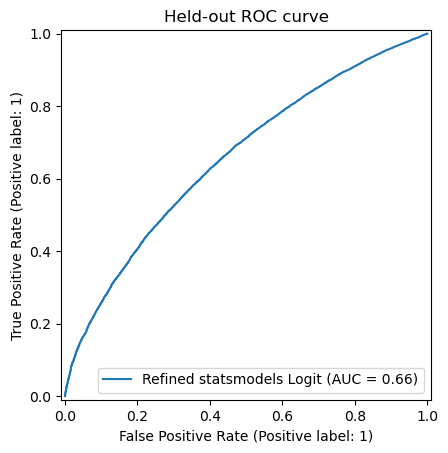

In [2]:
auc = roc_auc_score(y_test, probability_good)
gini = 2 * auc - 1
predicted_good = (probability_good >= 0.5).astype(int)
confusion = confusion_matrix(y_test, predicted_good)
metrics = pd.DataFrame({'metric': ['AUC', 'Gini'], 'value': [auc, gini]})
display(metrics)
display(pd.DataFrame(confusion, index=['actual bad', 'actual good'], columns=['predicted bad', 'predicted good']))

from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, probability_good, name='Refined statsmodels Logit')
plt.title('Held-out ROC curve')
plt.show()

At the displayed 0.5 `P(good)` threshold, no held-out bad rows are predicted bad, so bad-class recall is zero. Threshold selection and calibration are required before classification use; AUC and Gini still describe ranking discrimination.

## 300–850 scorecard

This linear rescaling is an illustrative interpretation layer. It is not a production scorecard calibration or lending policy. It uses the same unpenalized refined statsmodels specification and train-only preprocessing as notebook 03.

In [3]:
min_score, max_score = 300, 850

# Fix the 300–850 scale using the training refined-logit distribution only, then apply it unchanged to test rows.
training_logit_good = model.predict(refined_design_train, linear=True)
test_logit_good = model.predict(refined_design_test, linear=True)
low, high = np.quantile(training_logit_good, [0.01, 0.99])
score = (min_score + (test_logit_good - low) * (max_score - min_score) / (high - low)).clip(min_score, max_score).round().astype(int)
scorecard = pd.DataFrame({'score': score, 'PD': PD, 'P(good)': probability_good}, index=y_test.index)
scorecard.head(10)

/Users/joseclaudio/opt/anaconda3/envs/portfolio/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:530: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


,score,PD,P(good)
395346,545,0.111152,0.888848
376583,822,0.034882,0.965118
297790,528,0.119167,0.880833
47347,643,0.074659,0.925341
446772,447,0.162445,0.837555
415533,806,0.037288,0.962712
355671,611,0.085082,0.914918
11223,793,0.039457,0.960543
411384,649,0.072642,0.927358
21993,705,0.057579,0.942421


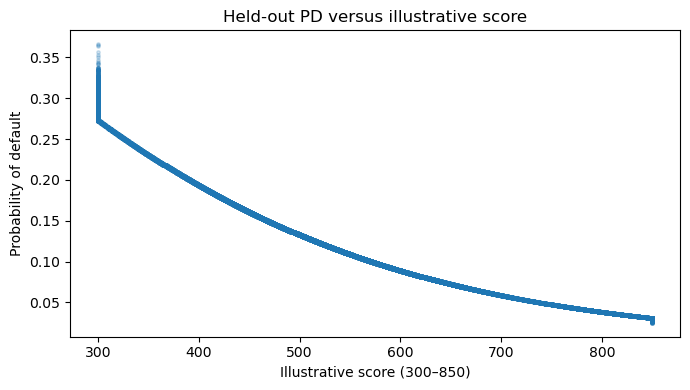

,score,PD
score,1.000000,-0.959171
PD,-0.959171,1.000000


In [4]:
plt.figure(figsize=(7, 4))
plt.scatter(scorecard['score'], scorecard['PD'], s=6, alpha=0.2)
plt.title('Held-out PD versus illustrative score')
plt.xlabel('Illustrative score (300–850)')
plt.ylabel('Probability of default')
plt.tight_layout()
plt.show()
scorecard[['score', 'PD']].corr()

## Historical and educational limitations

These results use historical Lending Club observations and a bad-status proxy, not a fixed performance-horizon default definition. They do not establish present-day performance, fairness, calibration, stability, approval rules, or regulatory suitability. Validate and govern any real PD or scorecard model separately.